# Image segmentation

UNet is a convolutional network that was designed to segment biomedical images. Its success rates are high even with few images in the training set. In this notebook you will learn to implement and use an UNet for image segmentation.

Requirements:
- matplotlib
- torch
- torchvision
- glob

## The problem

Develop a methodology to segment automatically mouse embryos from microscopy images [source](https://bbbc.broadinstitute.org/BBBC003). The dataset contains 15 grayscale images with their corresponding binary masks.

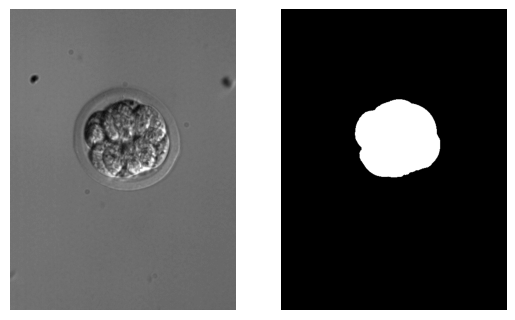

In [1]:
import matplotlib.pyplot as plt

# Aux function that shows an image and its corresponding mask in the same figure
def show(image, mask, title=None):
    fig, ax = plt.subplots(1,2)
    ax[0].imshow(image, cmap="gray")
    ax[0].axis('off')
    if title is not None:
        fig.suptitle(title)
    ax[1].imshow(mask, cmap="gray")
    ax[1].axis('off')
    plt.show()
    

im = plt.imread("res/unet/images/7_19_M1E18.tif")
mask = plt.imread("res/unet/masks/7_19_M1E18.tif")
show(im,mask)




## UNet
We are going to segment the images using an UNet. To this end, we are going to follow the next steps:

1. Define the net architecture
2. Generate a training and a validation dataset
3. Train the net
4. Validate the results


First, we set where the code will be run.

In [2]:
import torch

if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
device = torch.device(device_name)
print(f"Code runs in {device}")


Code runs in cuda


### Step 1: Model architecture

You can find online source code for the typical network architectures. In this notebook, we will use [this source code](https://github.com/usuyama/pytorch-unet).

In [3]:
import torch.nn as nn

def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True),
    )   


class UNet(nn.Module):

    def __init__(self, input_channels, n_class):
        super().__init__()
                
        self.dconv_down1 = double_conv(input_channels, 64)
        self.dconv_down2 = double_conv(64, 128)
        self.dconv_down3 = double_conv(128, 256)
        self.dconv_down4 = double_conv(256, 512)        

        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)        
        
        self.dconv_up3 = double_conv(256 + 512, 256)
        self.dconv_up2 = double_conv(128 + 256, 128)
        self.dconv_up1 = double_conv(128 + 64, 64)
        
        self.conv_last = nn.Conv2d(64, n_class, 1)
        
        
    def forward(self, x):
        conv1 = self.dconv_down1(x)
        x = self.maxpool(conv1)

        conv2 = self.dconv_down2(x)
        x = self.maxpool(conv2)
        
        conv3 = self.dconv_down3(x)
        x = self.maxpool(conv3)   
        
        x = self.dconv_down4(x)
        
        x = self.upsample(x)        
        x = torch.cat([x, conv3], dim=1)
        
        x = self.dconv_up3(x)
        x = self.upsample(x)        
        x = torch.cat([x, conv2], dim=1)       

        x = self.dconv_up2(x)
        x = self.upsample(x)        
        x = torch.cat([x, conv1], dim=1)   
        
        x = self.dconv_up1(x)
        
        out = self.conv_last(x)
        
        return out

### Step 2: Load the data

In this step, we are going to load the data by extending the torch class `Dataset`. 

Since the number of examples in our dataset is small, we can apply some transformations (rotations, traslations, blur, ...) to generate artificial samples and, this way, increase the number of samples in our dataset. This is called data augmentation. You can find more information about data augmentation and its implementation in the [pytorch documentation pages](https://pytorch.org/vision/stable/transforms.html).

In [4]:
from torch.utils.data import Dataset, DataLoader 
import torchvision.transforms as transforms
import glob
import os
import numpy as np
import random


class EmbryoDataset(Dataset):
    
    def __init__(self, image_path, mask_path, transform = None):
        super().__init__()
        # Load all the filenames with extension tif from the image_path directory
        self.img_files = glob.glob(os.path.join(image_path,'*.tif'))
        self.mask_files = []
        # We asume that each image has the same filename as its corresponding mask
        # but it is stored in another directory (mask_path)
        for img_path in self.img_files:
             self.mask_files.append(os.path.join(mask_path,os.path.basename(img_path)))
                
        self.transform = transform

    # Returns both the image and the mask
    def __getitem__(self, index):
            img_path = self.img_files[index]
            mask_path = self.mask_files[index]
            image = plt.imread(img_path)
            mask = plt.imread(mask_path)
            if len(mask.shape) > 2:
                # Some tiff images in this dataset has 4 identical channels :S
                mask = mask[:,:,0]
            
            # Apply the defined transformations to both image and mask
            if self.transform is not None:
                seed = np.random.randint(2147483647) # make a seed with numpy generator 
                random.seed(seed) # apply this seed to image transforms
                torch.manual_seed(seed) 
                image = self.transform(image)
                random.seed(seed) # apply the same seed to mask transforms
                torch.manual_seed(seed) 
                mask = self.transform(mask)
            else:
                t2 = transforms.Compose([
                        transforms.ToPILImage(),
                        transforms.ToTensor()])
                image = t2(image)
                mask = t2(mask)
                
                
            return image, mask

    def __len__(self):
        return len(self.img_files)


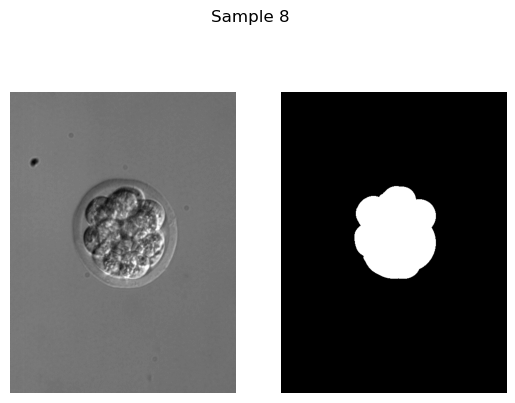

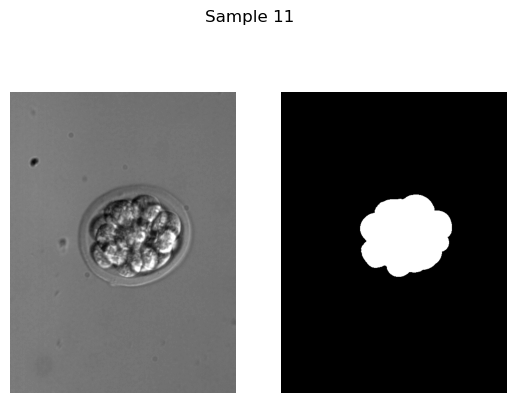

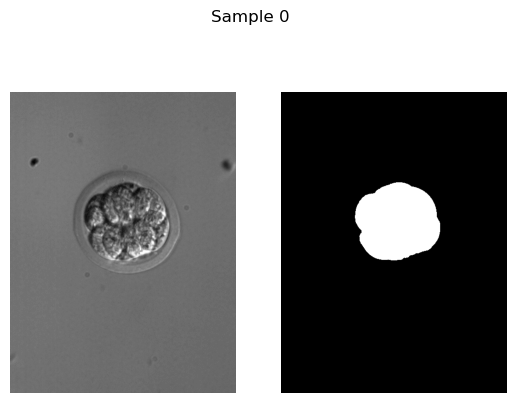

In [5]:
# Load some samples
simple_dataset = EmbryoDataset("res/unet/images", "res/unet/masks")
nsamples = 3
for _ in range(nsamples):
    idx = np.random.randint(0, len(simple_dataset))
    im, mask = simple_dataset[idx]
    show(im.squeeze(), mask.squeeze(), title=f"Sample {idx}")
    
# Divide the dataset into training and validation datasets
train_dataset, valid_dataset = torch.utils.data.random_split(simple_dataset, [12, 3])

## Step 3: Training

Once the training and validation datasets are created, the next step is training.

In [6]:
# Hyperparameters
BATCH_SIZE = 2
LR = 0.0001
N_INPUT_CHANNELS = 1
N_CLASSES = 1
THRESHOLD = 0.5
BATCH_SIZE = 2
EPOCHS = 30

# Model
unet = UNet(N_INPUT_CHANNELS,N_CLASSES)
unet.to(device)


# Loss function
bce_loss = nn.BCEWithLogitsLoss()

# Optimizer
adam_optimizer = torch.optim.Adam(unet.parameters(), lr=LR)

#### Exercise
Use the training function that you have implemented in the notebook 1b to train the UNet. Compute the accuracy as the IoU between the segmentation mask and the prediction. 
Feed the net with the original dataset without data augmentation and check the results.

**Hint**: In order to compute the IoU, the function `get_segmentation_masks` can be used to compute a segmentation mask from the outputs of the net. The output of the net is a positive floating point value. The sigmoid function restricts the output domain between 0 and 1. Since the output mask is binary, we use a threshold to set the output mask values to 0 or 1. Note that maybe you should tweak the default threshold.

#### Training the UNet without data augmentation

In this section, the UNet model is trained using the original dataset, without applying data augmentation.

This is a binary segmentation problem. Therefore, the network produces one output channel with raw logits. These logits are used directly with `BCEWithLogitsLoss`, which internally applies the sigmoid operation before computing the binary cross-entropy loss.

To evaluate the quality of the segmentation, the Intersection over Union metric is used. The IoU compares the predicted binary mask with the ground-truth mask:

\[
IoU = \frac{Intersection}{Union}
\]

An IoU value close to 1 means that the predicted mask is very similar to the real mask, while an IoU value close to 0 means that the prediction and the target mask barely overlap.

In [7]:
# Check image and mask properties before training
sample_image, sample_mask = simple_dataset[0]

print("Image shape:", sample_image.shape)
print("Mask shape:", sample_mask.shape)

print("Image min:", sample_image.min().item())
print("Image max:", sample_image.max().item())

print("Mask min:", sample_mask.min().item())
print("Mask max:", sample_mask.max().item())

print("Number of samples:", len(simple_dataset))

Image shape: torch.Size([1, 640, 480])
Mask shape: torch.Size([1, 640, 480])
Image min: 0.32156863808631897
Image max: 0.9921568632125854
Mask min: 0.0
Mask max: 1.0
Number of samples: 15


In [8]:
def get_segmentation_masks(outputs, threshold=0.3):
    probs = torch.sigmoid(outputs)
    masks = (probs > threshold) * 1.0
    return masks

In [9]:
def compute_iou(predicted_mask, target_mask, eps=1e-7):
    """
    Computes the Intersection over Union between a predicted binary mask
    and the corresponding ground-truth binary mask.
    """

    predicted_mask = predicted_mask.float()
    target_mask = target_mask.float()

    # Ensure that the target mask is binary
    target_mask = (target_mask > 0.5).float()

    intersection = (predicted_mask * target_mask).sum()
    union = predicted_mask.sum() + target_mask.sum() - intersection

    iou = (intersection + eps) / (union + eps)

    return iou

In [10]:
def train_one_epoch_segmentation(model, loader, loss_function, optimizer, device):
    model.train()

    total_loss = 0.0
    total_iou = 0.0
    count = 0

    for images, masks in loader:
        images = images.to(device).float()
        masks = masks.to(device).float()

        # Ensure binary masks
        masks = (masks > 0.5).float()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss_value = loss_function(outputs, masks)

        # Backpropagation
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()

        # Compute IoU
        predicted_masks = get_segmentation_masks(outputs, threshold=0.3)
        batch_iou = compute_iou(predicted_masks, masks)

        batch_size = images.shape[0]
        total_loss += loss_value.item() * batch_size
        total_iou += batch_iou.item() * batch_size
        count += batch_size

    return total_loss / count, total_iou / count

In [11]:
def validate_segmentation(model, loader, loss_function, device):
    model.eval()

    total_loss = 0.0
    total_iou = 0.0
    count = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device).float()
            masks = masks.to(device).float()

            # Ensure binary masks
            masks = (masks > 0.5).float()

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss_value = loss_function(outputs, masks)

            # Compute IoU
            predicted_masks = get_segmentation_masks(outputs, threshold=0.3)
            batch_iou = compute_iou(predicted_masks, masks)

            batch_size = images.shape[0]
            total_loss += loss_value.item() * batch_size
            total_iou += batch_iou.item() * batch_size
            count += batch_size

    return total_loss / count, total_iou / count

In [12]:
# def train_model(model, train_dataset, valid_dataset, device,
#                 optimizer, 
#                 loss,
#                 batch_size=128, 
#                 num_epochs=20,
#                 output_filename='trained-unet.pt'):
#     # Write your code here
#     torch.save(model, output_filename)
#     pass       

def train_model(model, train_dataset, valid_dataset, device,
                optimizer, 
                loss,
                batch_size=128, 
                num_epochs=20,
                output_filename='trained-unet.pt'):
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size)

    train_losses = []
    train_ious = []
    valid_losses = []
    valid_ious = []

    best_valid_iou = 0.0

    for epoch in range(num_epochs):

        train_loss, train_iou = train_one_epoch_segmentation(
            model=model,
            loader=train_loader,
            loss_function=loss,
            optimizer=optimizer,
            device=device
        )

        valid_loss, valid_iou = validate_segmentation(
            model=model,
            loader=valid_loader,
            loss_function=loss,
            device=device
        )

        train_losses.append(train_loss)
        train_ious.append(train_iou)
        valid_losses.append(valid_loss)
        valid_ious.append(valid_iou)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss = {train_loss:.4f} | "
            f"Train IoU = {train_iou:.4f} | "
            f"Validation Loss = {valid_loss:.4f} | "
            f"Validation IoU = {valid_iou:.4f}"
        )

        # Save the model with the highest validation IoU
        if valid_iou > best_valid_iou:
            best_valid_iou = valid_iou
            torch.save(model, output_filename)
            print(f"Best model saved with validation IoU = {best_valid_iou:.4f}")

    # Plot validation loss
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), valid_losses, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss through Epochs")
    plt.grid(True)
    plt.show()

    # Plot validation IoU
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), valid_ious, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Validation IoU")
    plt.title("Validation IoU through Epochs")
    plt.grid(True)
    plt.show()

    return train_losses, train_ious, valid_losses, valid_ious

### Selecting the best model using IoU

In the first training run, the validation loss decreased, but the validation IoU remained close to zero for many epochs. This suggests that the model was reducing the pixel-wise binary cross-entropy loss, but it was not necessarily producing good segmentation masks.

In binary segmentation problems, this can happen when the background class dominates the image. A model can obtain a relatively low loss by predicting mostly background, but this leads to poor overlap with the ground-truth mask.

For this reason, the best model will be selected according to the validation IoU instead of the validation loss. IoU is more appropriate for this task because it directly measures the overlap between the predicted mask and the real segmentation mask.

In [13]:
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
MPS available: False
Device: cuda
GPU: NVIDIA GeForce GTX 1650


Epoch 1/30 | Train Loss = 0.7036 | Train IoU = 0.0873 | Validation Loss = 0.6925 | Validation IoU = 0.0806
Best model saved with validation IoU = 0.0806
Epoch 2/30 | Train Loss = 0.6772 | Train IoU = 0.0873 | Validation Loss = 0.6307 | Validation IoU = 0.0806
Epoch 3/30 | Train Loss = 0.4794 | Train IoU = 0.0540 | Validation Loss = 0.3772 | Validation IoU = 0.0000
Epoch 4/30 | Train Loss = 0.3580 | Train IoU = 0.0000 | Validation Loss = 0.3498 | Validation IoU = 0.0000
Epoch 5/30 | Train Loss = 0.3402 | Train IoU = 0.0000 | Validation Loss = 0.2975 | Validation IoU = 0.0000
Epoch 6/30 | Train Loss = 0.3202 | Train IoU = 0.0000 | Validation Loss = 0.2982 | Validation IoU = 0.0000
Epoch 7/30 | Train Loss = 0.3162 | Train IoU = 0.0000 | Validation Loss = 0.2876 | Validation IoU = 0.0000
Epoch 8/30 | Train Loss = 0.3069 | Train IoU = 0.0000 | Validation Loss = 0.2861 | Validation IoU = 0.0000
Epoch 9/30 | Train Loss = 0.3035 | Train IoU = 0.0000 | Validation Loss = 0.2834 | Validation IoU 

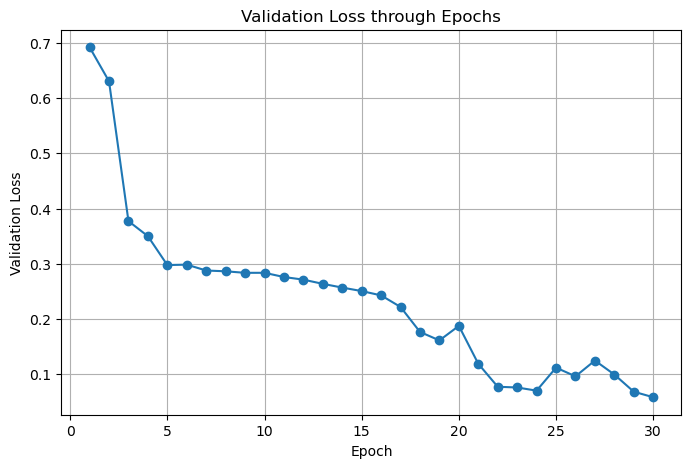

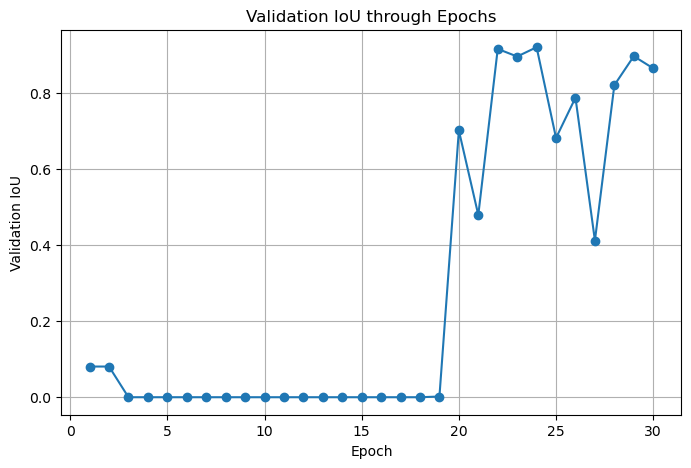

In [14]:
unet = UNet(N_INPUT_CHANNELS, N_CLASSES)
unet.to(device)

adam_optimizer = torch.optim.Adam(unet.parameters(), lr=LR)

history_unet = train_model(
    model=unet,
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    device=device,
    optimizer=adam_optimizer,
    loss=bce_loss,
    batch_size=BATCH_SIZE,
    num_epochs=EPOCHS,
    output_filename='trained-unet.pt'
)

### Step 4: Validate the results

After training we can check the results in the dataset.

### Visual validation of the segmentation results

After training, the best saved UNet model is loaded and applied to the validation dataset. The network outputs raw logits, so the sigmoid function and a threshold are used to obtain a binary segmentation mask.

The predicted mask is multiplied by the original image in order to visualize the segmented region. This allows a qualitative comparison between the predicted segmentation and the ground-truth mask.

In [15]:
def check_segmentation_results(model, dataset, threshold=0.5):
    model.eval()

    with torch.no_grad():
        for image, mask in dataset:
            image = image[None, :, :, :]
            image = image.to(device).float()
            mask = mask.to(device).float()

            output = model(image)
            predicted_mask = get_segmentation_masks(output, threshold)

            show(
                image.cpu().squeeze() * predicted_mask.cpu().squeeze(),
                mask.cpu().squeeze(),
                title="Segmentation masks"
            )

C:\Users\Hugo\AppData\Local\Temp\ipykernel_25764\110595969.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet = torch.load('trained-unet.pt', map_location=device)


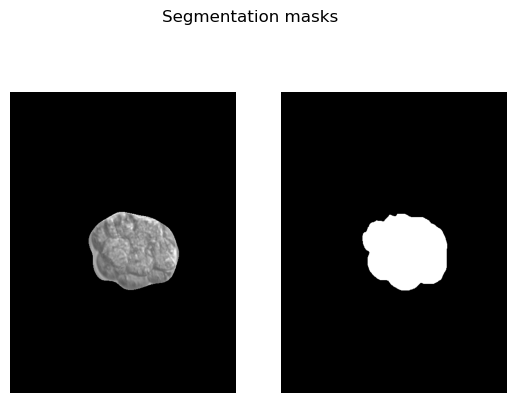

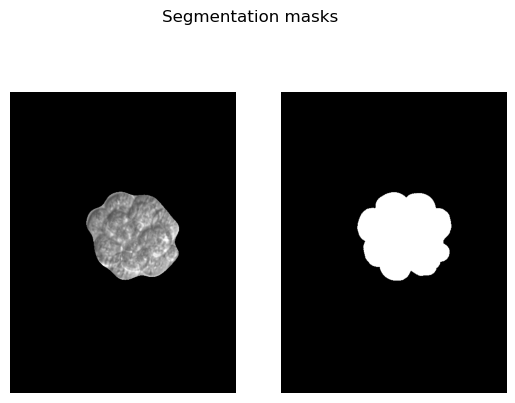

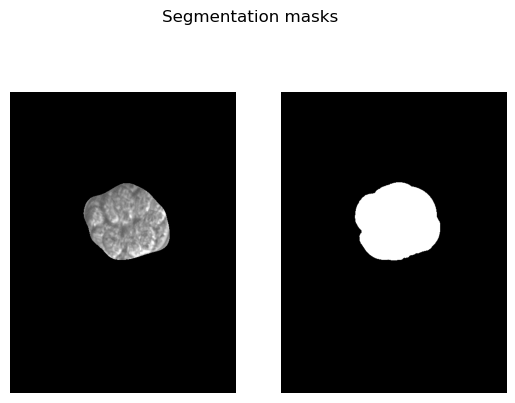

In [16]:
unet = torch.load('trained-unet.pt', map_location=device)
unet.to(device)

check_segmentation_results(unet, valid_dataset, threshold=0.3)

#### Exercise
Modify the function `check_segmentation_results` to include the IoU metric.

### Segmentation validation with IoU

In addition to visually inspecting the predicted masks, the IoU metric is computed for each validation image. This provides a quantitative measure of the overlap between the predicted mask and the ground-truth mask.

The IoU is shown in the title of each result, making it easier to compare the visual segmentation quality with the numerical metric.

In [17]:
def check_segmentation_results_with_acc(model, dataset, threshold=0.5):
    model.eval()

    ious = []

    with torch.no_grad():
        for image, mask in dataset:
            image = image[None, :, :, :]
            image = image.to(device).float()
            mask = mask.to(device).float()

            # Ensure binary ground-truth mask
            mask = (mask > 0.5).float()

            output = model(image)
            predicted_mask = get_segmentation_masks(output, threshold)

            iou = compute_iou(predicted_mask.squeeze(), mask.squeeze())
            ious.append(iou.item())

            show(
                image.cpu().squeeze() * predicted_mask.cpu().squeeze(),
                mask.cpu().squeeze(),
                title=f"Segmentation mask: IoU {iou:.4f}"
            )

    mean_iou = np.mean(ious)
    print(f"Mean IoU: {mean_iou:.4f}")

    return mean_iou

C:\Users\Hugo\AppData\Local\Temp\ipykernel_25764\22830723.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet = torch.load('trained-unet.pt', map_location=device)


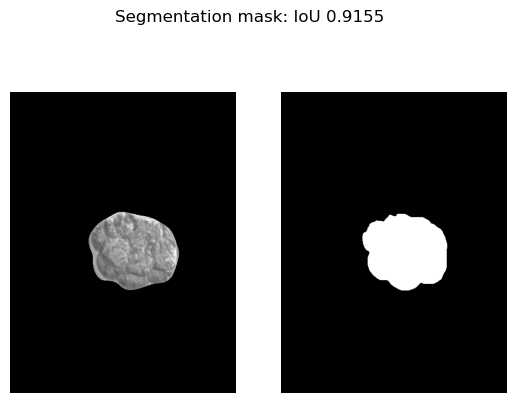

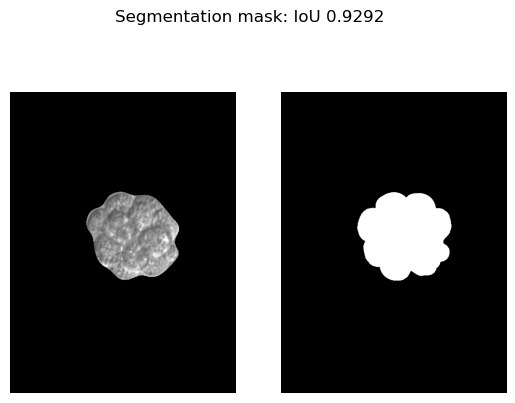

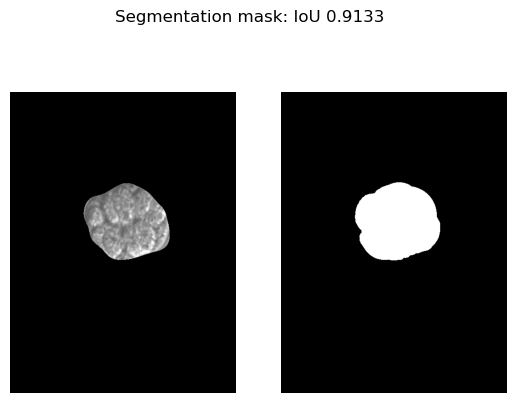

Mean IoU: 0.9194


In [18]:
unet = torch.load('trained-unet.pt', map_location=device)
unet.to(device)

mean_iou_unet = check_segmentation_results_with_acc(
    model=unet,
    dataset=valid_dataset,
    threshold=0.3
)

### Threshold selection

The UNet output is converted into a binary mask using a threshold after the sigmoid activation. Since the optimal threshold is not necessarily 0.5, different threshold values are tested on the validation set.

The threshold with the highest mean IoU can be selected for the final visual evaluation.

Threshold: 0.1


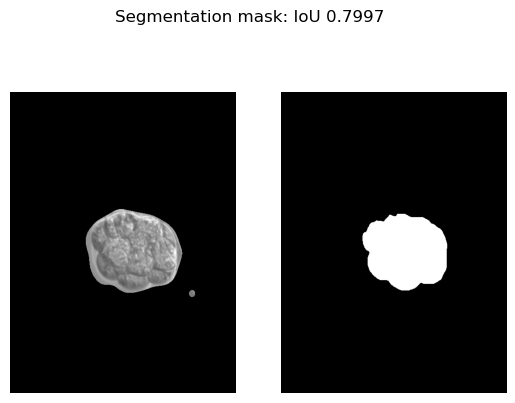

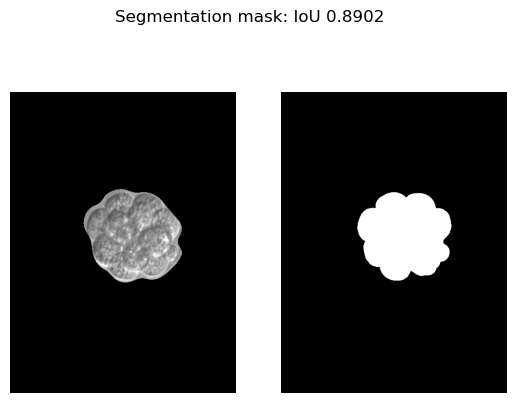

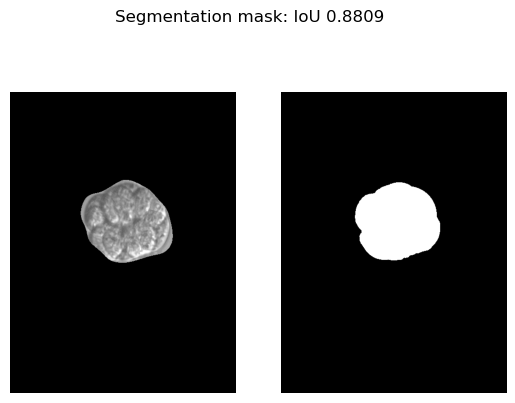

Mean IoU: 0.8569
Threshold: 0.2


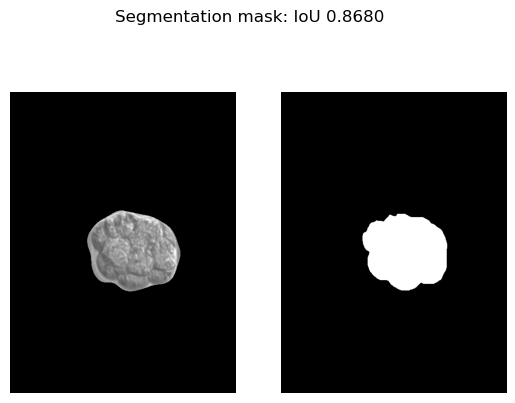

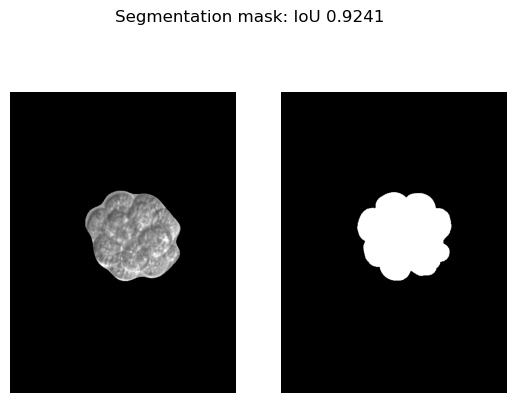

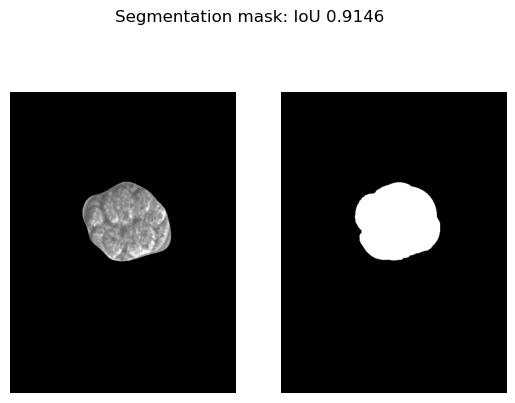

Mean IoU: 0.9022
Threshold: 0.3


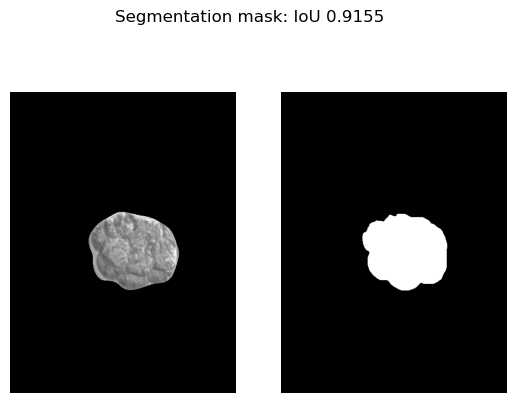

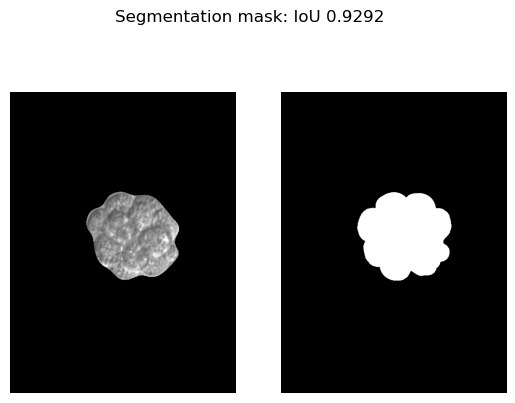

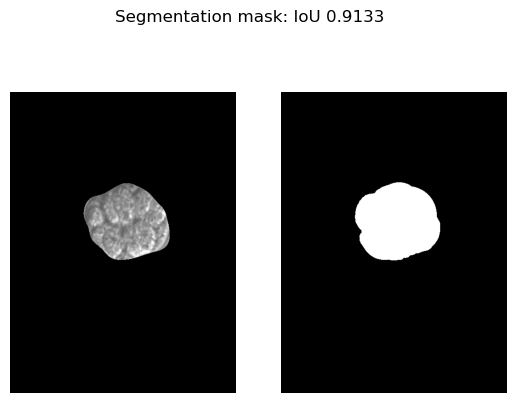

Mean IoU: 0.9194
Threshold: 0.4


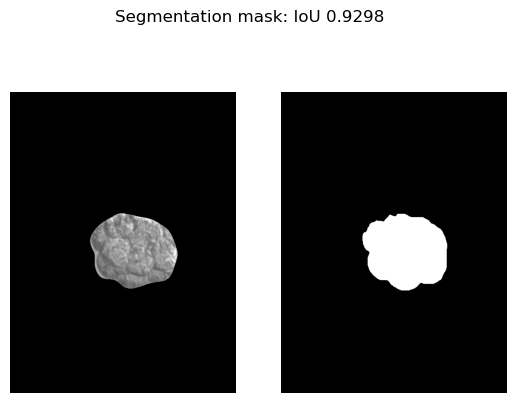

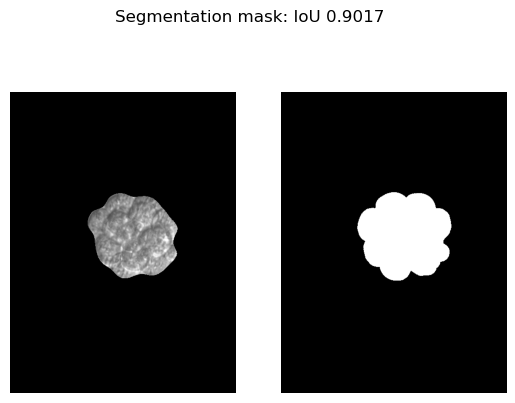

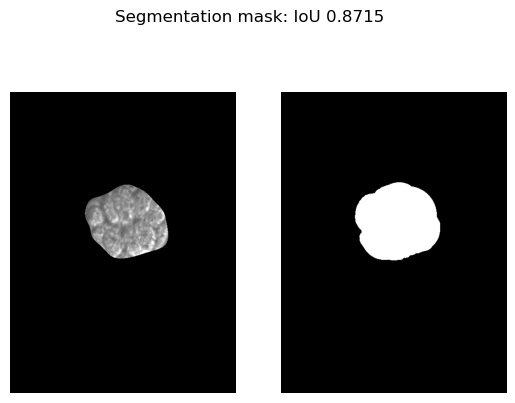

Mean IoU: 0.9010
Threshold: 0.5


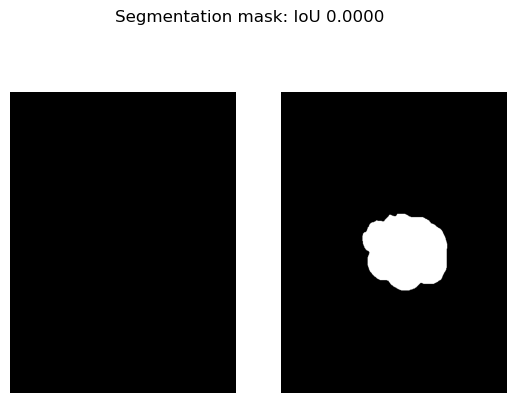

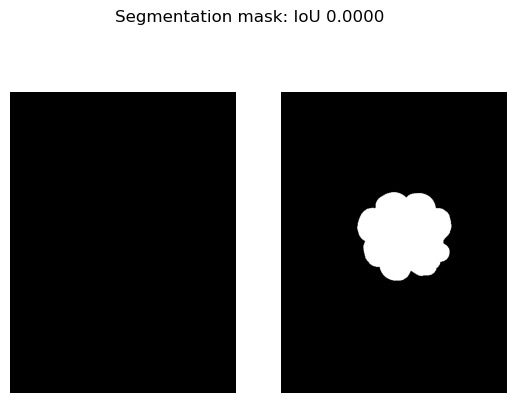

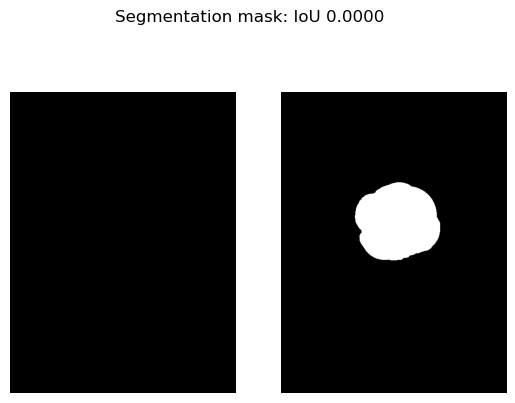

Mean IoU: 0.0000


In [19]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for threshold in thresholds:
    print("=" * 50)
    print(f"Threshold: {threshold}")
    
    mean_iou = check_segmentation_results_with_acc(
        model=unet,
        dataset=valid_dataset,
        threshold=threshold
    )
    
    threshold_results.append({
        "Threshold": threshold,
        "Mean IoU": mean_iou
    })

In [20]:
import pandas as pd

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,Threshold,Mean IoU
0,0.1,8.569231e-01
1,0.2,9.022130e-01
2,0.3,9.193658e-01
3,0.4,9.009820e-01
4,0.5,4.078088e-12


In [21]:
best_threshold = threshold_results_df.loc[
    threshold_results_df["Mean IoU"].idxmax(),
    "Threshold"
]

print(f"Best threshold: {best_threshold}")

Best threshold: 0.3


### Exercise

Define a set of suitable transforms, train the UNet with data augmentation and check the results.

### Training with data augmentation

Since the dataset contains only 15 images, data augmentation is used to artificially increase the variability of the training samples. Random horizontal flips, vertical flips and rotations are applied.

The same random transformation must be applied to the image and to its corresponding mask. Otherwise, the mask would no longer match the image. The dataset class handles this by using the same random seed for both transformations.

Only geometric transformations are used, because intensity transformations or blur would also affect the binary masks.

In [22]:
# Load images with data augmentation
transf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ToTensor()
])

augmented_dataset = EmbryoDataset(
    "res/unet/images",
    "res/unet/masks",
    transform=transf
)

train_dataset_aug, valid_dataset_aug = torch.utils.data.random_split(
    augmented_dataset,
    [12, 3]
)

Epoch 1/30 | Train Loss = 0.6217 | Train IoU = 0.0849 | Validation Loss = 0.5123 | Validation IoU = 0.0904
Best model saved with validation IoU = 0.0904
Epoch 2/30 | Train Loss = 0.3690 | Train IoU = 0.0137 | Validation Loss = 0.3481 | Validation IoU = 0.0000
Epoch 3/30 | Train Loss = 0.3113 | Train IoU = 0.0000 | Validation Loss = 0.3212 | Validation IoU = 0.0000
Epoch 4/30 | Train Loss = 0.2940 | Train IoU = 0.0000 | Validation Loss = 0.2955 | Validation IoU = 0.0000
Epoch 5/30 | Train Loss = 0.2795 | Train IoU = 0.0000 | Validation Loss = 0.2843 | Validation IoU = 0.0000
Epoch 6/30 | Train Loss = 0.2730 | Train IoU = 0.0000 | Validation Loss = 0.2784 | Validation IoU = 0.0000
Epoch 7/30 | Train Loss = 0.2630 | Train IoU = 0.0000 | Validation Loss = 0.2659 | Validation IoU = 0.0000
Epoch 8/30 | Train Loss = 0.2560 | Train IoU = 0.0000 | Validation Loss = 0.2660 | Validation IoU = 0.0000
Epoch 9/30 | Train Loss = 0.2511 | Train IoU = 0.0000 | Validation Loss = 0.2553 | Validation IoU 

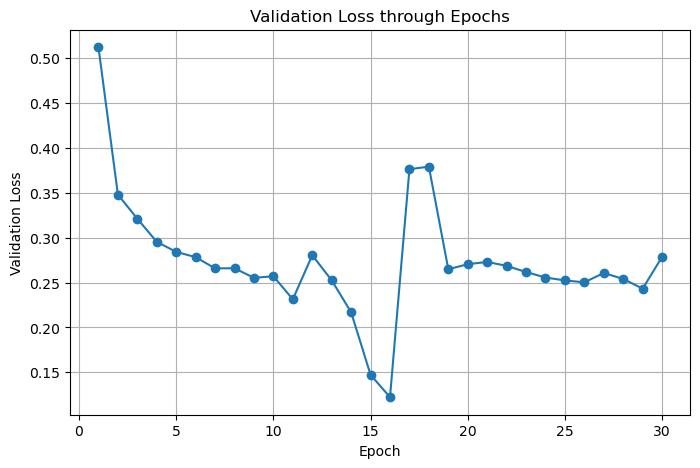

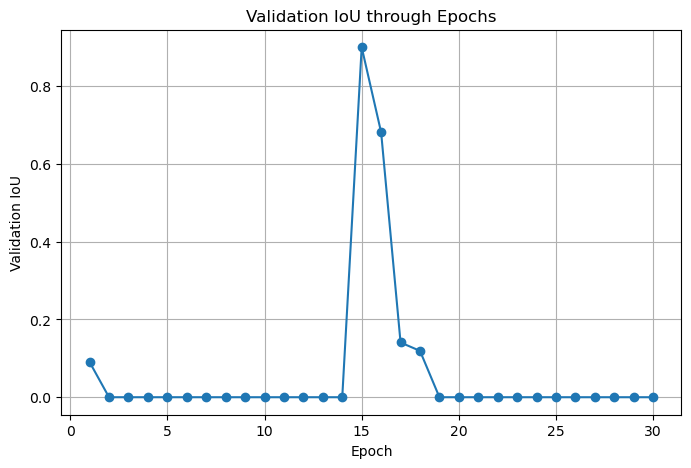

In [23]:
# Hyperparameters
BATCH_SIZE = 1 # I use a smaller batch size for the augmented dataset to reduce memory usage (I have a GPU with only 4GB of VRAM)
LR = 0.0001
N_INPUT_CHANNELS = 1
N_CLASSES = 1
THRESHOLD = 0.3
EPOCHS = 30

# Model
unet_augmented = UNet(N_INPUT_CHANNELS, N_CLASSES)
unet_augmented.to(device)

# Optimizer
adam_optimizer_aug = torch.optim.Adam(unet_augmented.parameters(), lr=LR)

history_unet_augmented = train_model(
    model=unet_augmented,
    train_dataset=train_dataset_aug,
    valid_dataset=valid_dataset_aug,
    device=device,
    optimizer=adam_optimizer_aug,
    loss=bce_loss,
    batch_size=BATCH_SIZE,
    num_epochs=EPOCHS,
    output_filename='trained-unet-augmented.pt'
)

C:\Users\Hugo\AppData\Local\Temp\ipykernel_25764\886410792.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  unet_augmented = torch.load('trained-unet-augmented.pt', map_l

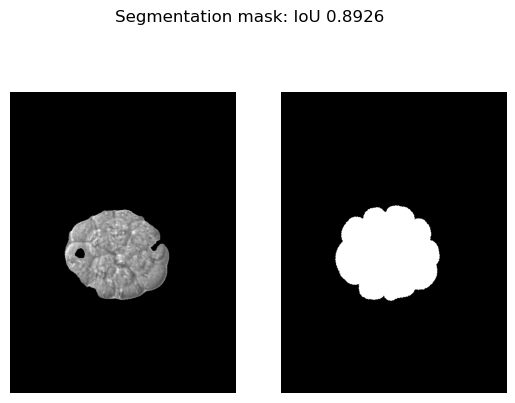

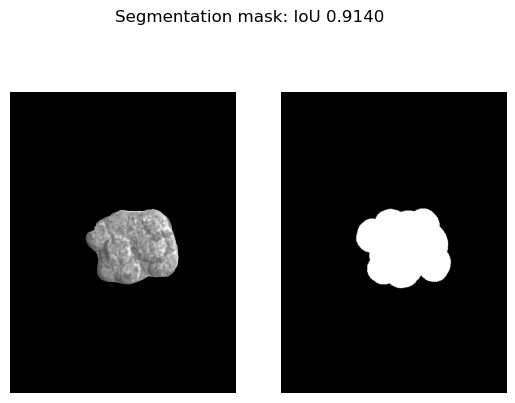

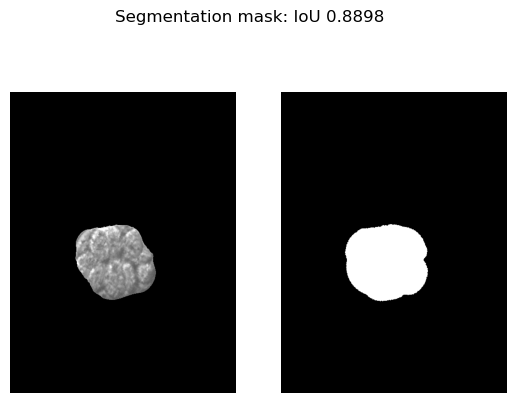

Mean IoU: 0.8988


In [24]:
unet_augmented = torch.load('trained-unet-augmented.pt', map_location=device)
unet_augmented.to(device)

mean_iou_unet_augmented = check_segmentation_results_with_acc(
    model=unet_augmented,
    dataset=valid_dataset_aug,
    threshold=THRESHOLD
)

In [25]:
segmentation_results = pd.DataFrame([
    {
        "Model": "UNet",
        "Data augmentation": "No",
        "Validation Mean IoU": mean_iou_unet
    },
    {
        "Model": "UNet",
        "Data augmentation": "Yes",
        "Validation Mean IoU": mean_iou_unet_augmented
    }
])

segmentation_results

,Model,Data augmentation,Validation Mean IoU
0,UNet,No,0.919366
1,UNet,Yes,0.898789


The UNet model was trained for binary segmentation of mouse embryo microscopy images. The model was first trained using the original dataset without data augmentation, and then trained again using random geometric transformations.

The IoU metric was used to evaluate segmentation quality, since it directly measures the overlap between the predicted mask and the ground-truth mask. This is more appropriate than standard pixel accuracy, especially when the background class dominates the image.

Data augmentation is especially useful in this problem because the dataset contains only 15 images. By applying random flips and rotations, the model observes more variability during training, which can help reduce overfitting and improve generalization.

The final comparison shows whether data augmentation improved the validation IoU with respect to the baseline UNet trained on the original dataset.